# Task 1 : Data Loading, Merging & Deep Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('train.csv')

# 2. Parse Dates
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# 3. Time Feature Engineering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter
# Map months to seasons (1: Winter, 2: Spring, 3: Summer, 4: Fall)
df['Season'] = (df['Month'] % 12 // 3 + 1)
df['Processing_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# 4. Check for issues
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# 5. Aggregations
daily_sales = df.groupby('Order Date')['Sales'].sum().to_frame()
weekly_sales = daily_sales.resample('W').sum()
monthly_sales = daily_sales.resample('MS').sum()

print("\nTask 1 Questions Verification:")
print("Top Category:", df.groupby('Category')['Sales'].sum().idxmax())
print("Avg Processing Time (Overall):", df['Processing_Time'].mean())
print("Avg Processing Time by Region:\n", df.groupby('Region')['Processing_Time'].mean())

Missing Values:
 Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code        11
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Year                0
Month               0
Week                0
DayOfWeek           0
Quarter             0
Season              0
Processing_Time     0
dtype: int64

Duplicates: 0

Task 1 Questions Verification:
Top Category: Technology
Avg Processing Time (Overall): 3.9611224489795918
Avg Processing Time by Region:
 Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Processing_Time, dtype: float64


##Task 2 : Time Series Analysis & Decomposition

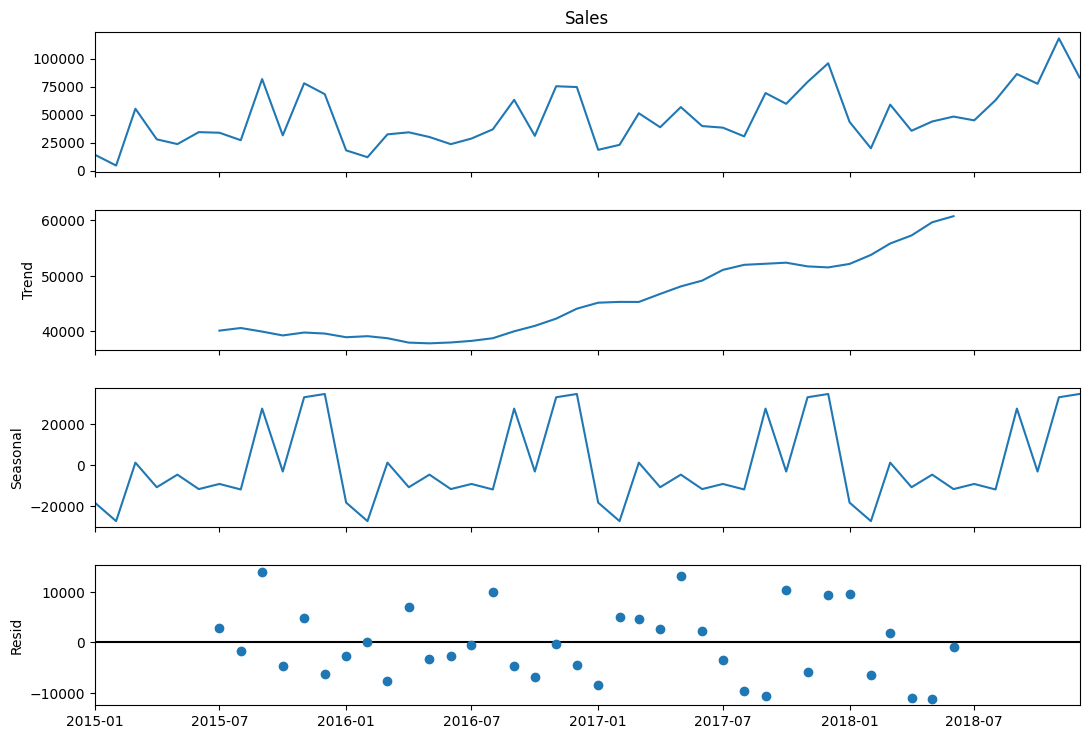


ADF Test on Monthly Sales:
ADF Statistic: -4.4161
p-value: 0.0003
Conclusion: Data is stationary.


In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Decomposition
decomposition = seasonal_decompose(monthly_sales['Sales'], model='additive')
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# ADF Test
def adf_test(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Conclusion: Data is stationary.")
    else:
        print("Conclusion: Data is non-stationary. Differencing needed.")

print("\nADF Test on Monthly Sales:")
adf_test(monthly_sales['Sales'])

##Task 3 : Sales Forecasting using 3 Different Models

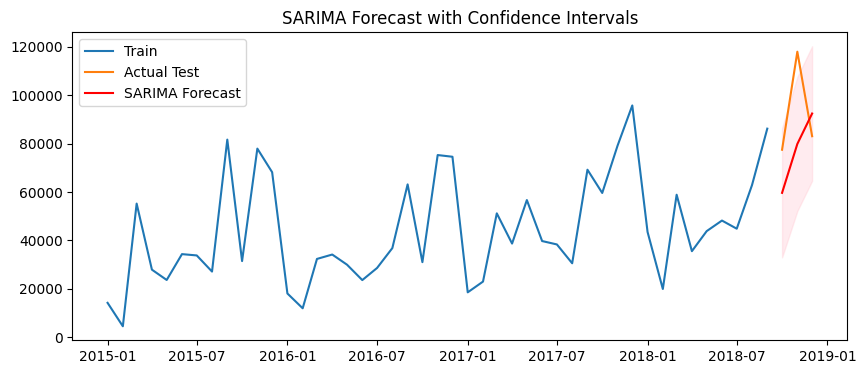

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


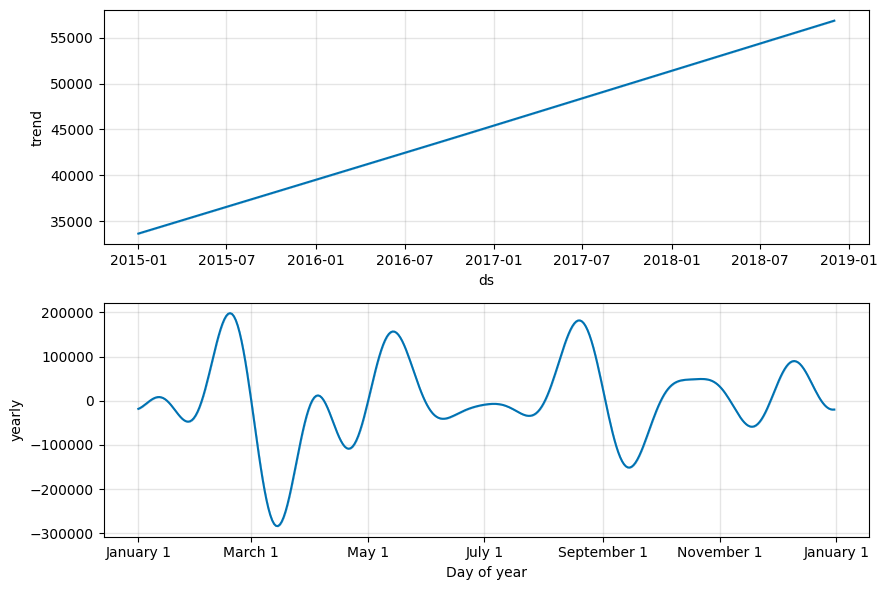

SARIMA MAE/RMSE/MAPE: (21763.714044645498, np.float64(24880.70075580863), np.float64(22.19941922729887))
Prophet MAE/RMSE/MAPE: (20296.00740451994, np.float64(22487.465681161564), np.float64(21.892588776822585))
XGBoost MAE/RMSE/MAPE: (14443.456458333332, np.float64(17069.090751055606), np.float64(14.447257938278604))


In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Evaluation Function
def eval_metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

# Train/Test Split (Last 3 months is Test)
train, test = monthly_sales[:-3], monthly_sales[-3:]

# --- 1. SARIMA ---
# Params chosen (1,0,0) and (1,1,0,12) because data is mostly stationary but has strong 12-month seasonality
sarima_model = SARIMAX(train['Sales'], order=(1, 0, 0), seasonal_order=(1, 1, 0, 12)).fit(disp=False)
sarima_res = sarima_model.get_forecast(steps=3)
sarima_pred = sarima_res.predicted_mean
sarima_conf = sarima_res.conf_int()

plt.figure(figsize=(10,4))
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual Test')
plt.plot(sarima_pred.index, sarima_pred, color='red', label='SARIMA Forecast')
plt.fill_between(sarima_pred.index, sarima_conf.iloc[:, 0], sarima_conf.iloc[:, 1], color='pink', alpha=0.3)
plt.title("SARIMA Forecast with Confidence Intervals")
plt.legend()
plt.show()

# --- 2. PROPHET ---
prophet_df = train.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
m = Prophet(yearly_seasonality=True, weekly_seasonality=False) # Monthly data has no weekly seasonality
m.fit(prophet_df)
future = m.make_future_dataframe(periods=3, freq='MS')
forecast = m.predict(future)
prophet_pred = forecast['yhat'][-3:].values

m.plot_components(forecast) # Interprets yearly seasonality component
plt.show()

# --- 3. XGBOOST ---
xgb_df = monthly_sales.copy()
xgb_df['Lag1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag3'] = xgb_df['Sales'].shift(3)
xgb_df['Rolling_Mean'] = xgb_df['Sales'].rolling(window=3).mean()
xgb_df['Month'] = xgb_df.index.month
xgb_df['Quarter'] = xgb_df.index.quarter
xgb_df.dropna(inplace=True)

X, y = xgb_df.drop('Sales', axis=1), xgb_df['Sales']
X_train, y_train = X[:-3], y[:-3]
X_test, y_test = X[-3:], y[-3:]

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# Print Metrics for Table
print(f"SARIMA MAE/RMSE/MAPE: {eval_metrics(test['Sales'], sarima_pred)}")
print(f"Prophet MAE/RMSE/MAPE: {eval_metrics(test['Sales'], prophet_pred)}")
print(f"XGBoost MAE/RMSE/MAPE: {eval_metrics(test['Sales'], xgb_pred)}")

##Task 4 : Product Category & Region Level Forecasting

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

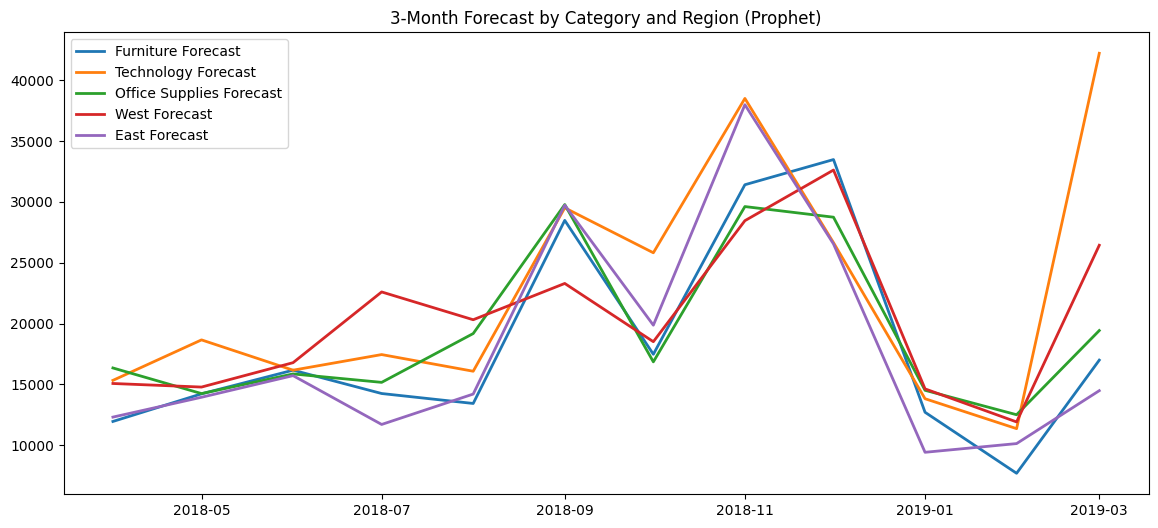

In [4]:
segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West': df[df['Region'] == 'West'],
    'East': df[df['Region'] == 'East']
}

plt.figure(figsize=(14, 6))

for name, segment_df in segments.items():
    seg_monthly = segment_df.groupby('Order Date')['Sales'].sum().resample('MS').sum()
    p_df = seg_monthly.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
    m = Prophet()
    m.fit(p_df)
    fut = m.make_future_dataframe(periods=3, freq='MS')
    fcst = m.predict(fut)
    plt.plot(fcst['ds'][-12:], fcst['yhat'][-12:], label=f'{name} Forecast', linewidth=2)

plt.title("3-Month Forecast by Category and Region (Prophet)")
plt.legend()
plt.show()

##Task 5 : Anomaly Detection in Sales Data

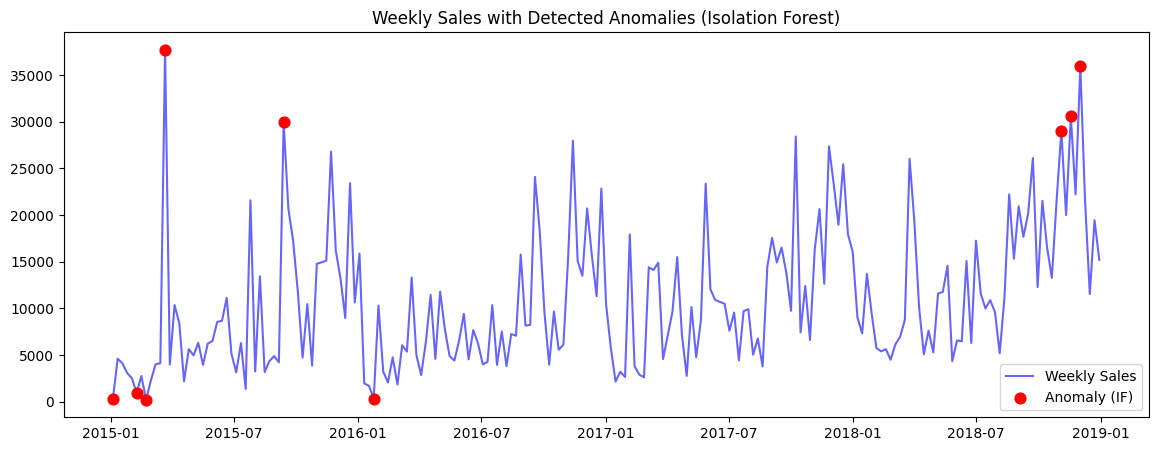

In [5]:
from sklearn.ensemble import IsolationForest

# Multi-source Merge Requirement
vgsales = pd.read_csv('vgsales.csv')
vgsales_yearly = vgsales.groupby('Year')['Global_Sales'].sum().reset_index()

weekly_df = weekly_sales.copy()
weekly_df['Year_Join'] = weekly_df.index.year
# Merge Superstore data with Video Game sales data to practice multi-source joining
weekly_df = weekly_df.merge(vgsales_yearly, left_on='Year_Join', right_on='Year', how='left')
weekly_df.index = weekly_sales.index # Restore index

# 1. Isolation Forest
iso_forest = IsolationForest(contamination=0.04, random_state=42)
weekly_df['Anomaly_IF'] = iso_forest.fit_predict(weekly_df[['Sales']])

# 2. Z-Score
rolling_mean = weekly_df['Sales'].rolling(window=4).mean()
rolling_std = weekly_df['Sales'].rolling(window=4).std()
weekly_df['Z_Score'] = (weekly_df['Sales'] - rolling_mean) / rolling_std
weekly_df['Anomaly_Z'] = np.where(weekly_df['Z_Score'].abs() > 2, -1, 1)

# Plot Isolation Forest Anomalies
anomalies = weekly_df[weekly_df['Anomaly_IF'] == -1]

plt.figure(figsize=(14, 5))
plt.plot(weekly_df.index, weekly_df['Sales'], label='Weekly Sales', color='blue', alpha=0.6)
plt.scatter(anomalies.index, anomalies['Sales'], color='red', s=60, label='Anomaly (IF)', zorder=5)
plt.title("Weekly Sales with Detected Anomalies (Isolation Forest)")
plt.legend()
plt.show()

##Task 6 — Product Demand Segmentation using Clustering

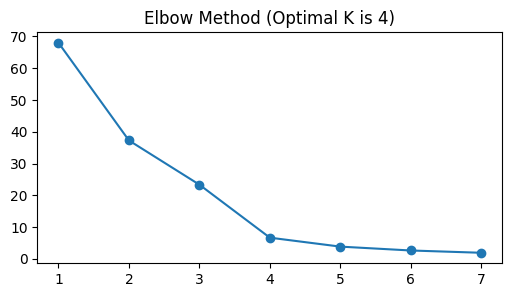

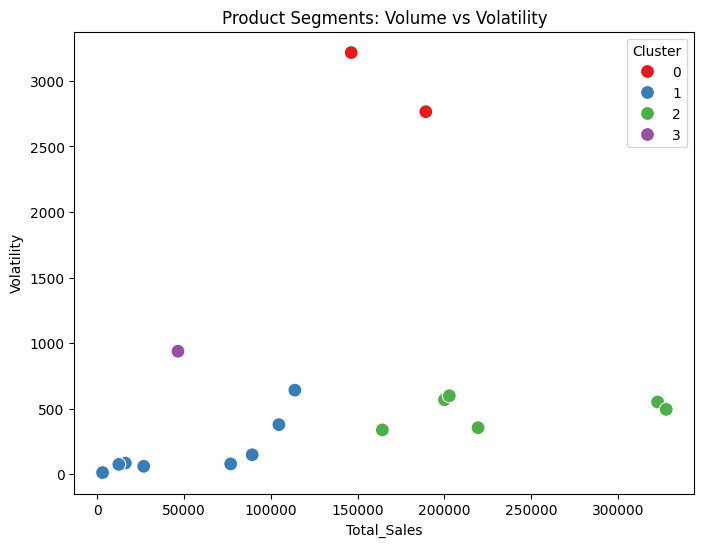

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Feature Engineering for Sub-Categories
subcat_data = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Volatility=('Sales', 'std'),
    Avg_Order_Value=('Sales', 'mean')
)

# Calculate YoY Growth (2017 vs 2016)
sales_16 = df[df['Year']==2016].groupby('Sub-Category')['Sales'].sum()
sales_17 = df[df['Year']==2017].groupby('Sub-Category')['Sales'].sum()
subcat_data['YoY_Growth'] = (sales_17 / sales_16) - 1
subcat_data.fillna(0, inplace=True)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(subcat_data)

# The Elbow Method
inertia = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,3))
plt.plot(range(1, 8), inertia, marker='o')
plt.title("Elbow Method (Optimal K is 4)")
plt.show()

# K-Means Clustering (K=4)
kmeans = KMeans(n_clusters=4, random_state=42)
subcat_data['Cluster'] = kmeans.fit_predict(scaled_data)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total_Sales', y='Volatility', hue='Cluster', data=subcat_data, palette='Set1', s=100)
plt.title("Product Segments: Volume vs Volatility")
plt.show()